##Первичная обработка датасета

In [220]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

%matplotlib inline
warnings.filterwarnings('ignore')

In [5]:
who_df = pd.read_csv('/content/Life Expectancy Data.csv')
who_df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [6]:
who_df_2014 = who_df[who_df['Year'] == 2014]
who_df_nocountry = who_df_2014.drop('Country', axis=1)

In [7]:
who_df_nocountry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 2923
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             183 non-null    int64  
 1   Status                           183 non-null    object 
 2   Life expectancy                  183 non-null    float64
 3   Adult Mortality                  183 non-null    float64
 4   infant deaths                    183 non-null    int64  
 5   Alcohol                          182 non-null    float64
 6   percentage expenditure           183 non-null    float64
 7   Hepatitis B                      173 non-null    float64
 8   Measles                          183 non-null    int64  
 9    BMI                             181 non-null    float64
 10  under-five deaths                183 non-null    int64  
 11  Polio                            183 non-null    float64
 12  Total expenditure         

In [8]:
who_df_nocountry = who_df_nocountry.drop(columns=who_df_nocountry.columns[who_df_nocountry.isnull().mean() > 0.1])

In [9]:
who_df_nocountry

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
17,2014,Developing,77.5,8.0,0,4.51,428.749067,98.0,0,57.2,1,98.0,5.88,98.0,0.1,1.2,1.3,0.761,14.2
33,2014,Developing,75.4,11.0,21,0.01,54.237318,95.0,0,58.4,24,95.0,7.21,95.0,0.1,6.0,5.8,0.741,14.4
49,2014,Developing,51.7,348.0,67,8.33,23.965612,64.0,11699,22.7,101,68.0,3.31,64.0,2.0,8.5,8.3,0.527,11.4
65,2014,Developing,76.2,131.0,0,8.56,2422.999774,99.0,0,47.0,0,96.0,5.54,99.0,0.2,3.3,3.3,0.782,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,2014,Developing,73.9,158.0,9,6.47,0.000000,78.0,0,61.5,10,79.0,5.26,78.0,0.1,1.6,1.5,0.771,14.2
2875,2014,Developing,75.9,128.0,28,4.09,0.000000,95.0,15033,16.7,35,96.0,7.70,95.0,0.1,14.3,14.7,0.675,12.5
2891,2014,Developing,65.4,228.0,37,0.01,0.000000,73.0,815,4.4,47,67.0,5.64,73.0,0.1,13.7,13.5,0.500,9.0
2907,2014,Developing,61.1,314.0,28,0.01,196.667577,86.0,9,22.8,41,78.0,4.99,86.0,4.3,6.3,6.2,0.570,12.5


In [10]:
who_df_nocountry.info() #проверяем, что сработало

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 2923
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             183 non-null    int64  
 1   Status                           183 non-null    object 
 2   Life expectancy                  183 non-null    float64
 3   Adult Mortality                  183 non-null    float64
 4   infant deaths                    183 non-null    int64  
 5   Alcohol                          182 non-null    float64
 6   percentage expenditure           183 non-null    float64
 7   Hepatitis B                      173 non-null    float64
 8   Measles                          183 non-null    int64  
 9    BMI                             181 non-null    float64
 10  under-five deaths                183 non-null    int64  
 11  Polio                            183 non-null    float64
 12  Total expenditure         

In [11]:
who_df_final = who_df_nocountry.dropna()
who_df_final.info()
who_df_final

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 1 to 2923
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             163 non-null    int64  
 1   Status                           163 non-null    object 
 2   Life expectancy                  163 non-null    float64
 3   Adult Mortality                  163 non-null    float64
 4   infant deaths                    163 non-null    int64  
 5   Alcohol                          163 non-null    float64
 6   percentage expenditure           163 non-null    float64
 7   Hepatitis B                      163 non-null    float64
 8   Measles                          163 non-null    int64  
 9    BMI                             163 non-null    float64
 10  under-five deaths                163 non-null    int64  
 11  Polio                            163 non-null    float64
 12  Total expenditure         

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
17,2014,Developing,77.5,8.0,0,4.51,428.749067,98.0,0,57.2,1,98.0,5.88,98.0,0.1,1.2,1.3,0.761,14.2
33,2014,Developing,75.4,11.0,21,0.01,54.237318,95.0,0,58.4,24,95.0,7.21,95.0,0.1,6.0,5.8,0.741,14.4
49,2014,Developing,51.7,348.0,67,8.33,23.965612,64.0,11699,22.7,101,68.0,3.31,64.0,2.0,8.5,8.3,0.527,11.4
65,2014,Developing,76.2,131.0,0,8.56,2422.999774,99.0,0,47.0,0,96.0,5.54,99.0,0.2,3.3,3.3,0.782,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,2014,Developing,73.9,158.0,9,6.47,0.000000,78.0,0,61.5,10,79.0,5.26,78.0,0.1,1.6,1.5,0.771,14.2
2875,2014,Developing,75.9,128.0,28,4.09,0.000000,95.0,15033,16.7,35,96.0,7.70,95.0,0.1,14.3,14.7,0.675,12.5
2891,2014,Developing,65.4,228.0,37,0.01,0.000000,73.0,815,4.4,47,67.0,5.64,73.0,0.1,13.7,13.5,0.500,9.0
2907,2014,Developing,61.1,314.0,28,0.01,196.667577,86.0,9,22.8,41,78.0,4.99,86.0,4.3,6.3,6.2,0.570,12.5


Что еще я здесь сразу хочу сделать – сделать статус страны (категориальный признак) численным – иначе с ним потом будут сложности.

In [12]:
unique_values = who_df_final['Status'].unique()
print(unique_values)

['Developing' 'Developed']


In [13]:
who_df_final['Status'] = who_df_final['Status'].map(
    lambda x: 1 if x == 'Developed' else
              0 if x == 'Developing' else
              -1) #я на всякий случай оставила дефолтное значение, но хз зачем

##Предварительный анализ данных

###Обработка признака (*нужна только для классификации*)

Классификатор имеет смысл, когда по признаку, определять который мы учим модель, можно выделить несколько четко ограниченных групп (например, сорта ириса:)); в данном случае значения life expectancy практически не повторяются в пределах столбца, потому что они даны с точностью до десятых долей. Для работы с линейной регрессией такая точность – это, кажется, как раз очень хорошо, а вот для классификатора эти значения нужно разделить на группы. Ну, может быть, не нужно было, но я не поняла, как по-другому.

Ниже я смотрю, насколько равномерно распределяются данные по группам с округлением до


*   года
*   +-трех лет
*   пяти лет





<Axes: xlabel='Life expectancy ', ylabel='count'>

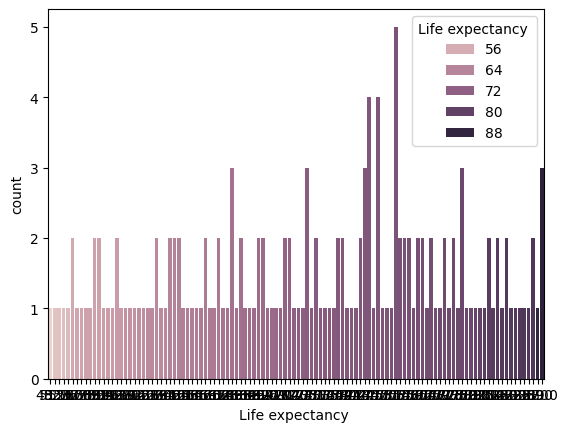

In [14]:
sns.countplot(x='Life expectancy ', hue='Life expectancy ', data=who_df_final)

На год с долями точно не смотрим – здесь данных ожидаемо мало и они еще и местами неравномерны.

<Axes: xlabel='Life expectancy ', ylabel='count'>

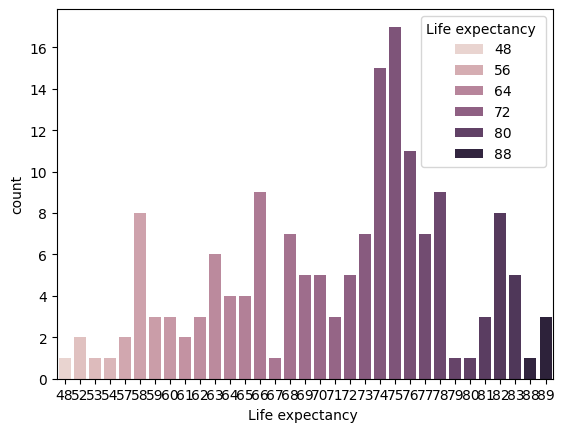

In [15]:
df_who_to_year = who_df_final.copy()
df_who_to_year['Life expectancy '] = df_who_to_year['Life expectancy '].map(lambda x: round(x))
sns.countplot(x='Life expectancy ', hue='Life expectancy ', data=df_who_to_year)

Здесь все еще хуже, потому что очень неравномерно. Пробуем округлить до 5 лет.

<Axes: xlabel='Life expectancy ', ylabel='count'>

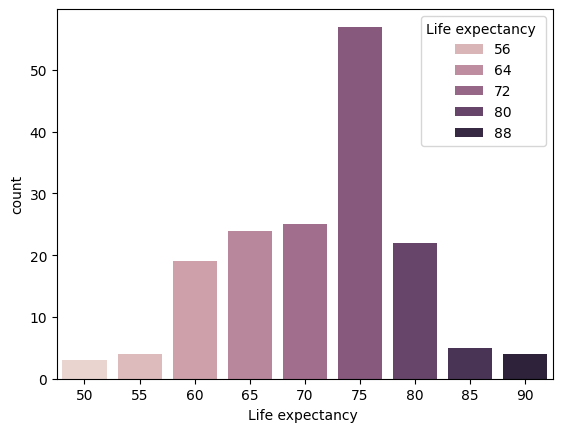

In [16]:
df_who_to_year = who_df_final.copy()
df_who_to_year['Life expectancy '] = df_who_to_year['Life expectancy '].apply(
                              lambda x: 5 * round(x/5) if pd.notnull(x) else x)
sns.countplot(x='Life expectancy ', hue='Life expectancy ', data=df_who_to_year)

Такое распределение равномерным тоже назвать нельзя, но может помочь такое деление:


*   меньше 60
*   далее отрезки по 5 лет
*   больше 80



<Axes: xlabel='Life expectancy ', ylabel='count'>

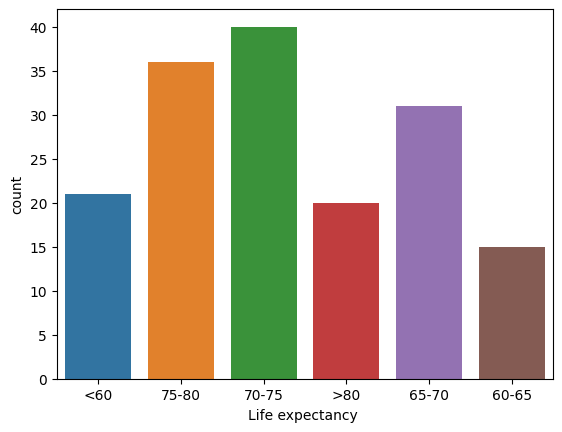

In [17]:
df_who_to_year = who_df_final.copy()
df_who_to_year['Life expectancy '] = df_who_to_year['Life expectancy '].apply(
    lambda x: '<60' if x < 60.1 else
              '60-65' if 60.1 <= x <= 65 else
              '65-70' if 65 < x <= 70 else
              '70-75' if 70 < x <= 75 else
              '75-80' if 75 < x <= 80 else
              '>80'
)
sns.countplot(x='Life expectancy ', hue='Life expectancy ', data=df_who_to_year)

Это все еще не очень хорошо, на самом деле (и можно было бы пытаться подобрать более точечные границы, типа "меньше 63", а не "меньше 60" – но как будто нам не нужна такой степени точность), но уже близко к истине. Пробуем проверить работу классификатора (как в конспекте с ирисами).

###Долгий подбор параметров

In [18]:
df_who_to_year = df_who_to_year.drop(columns=['Year']) #ну этот столбец просто не нужен

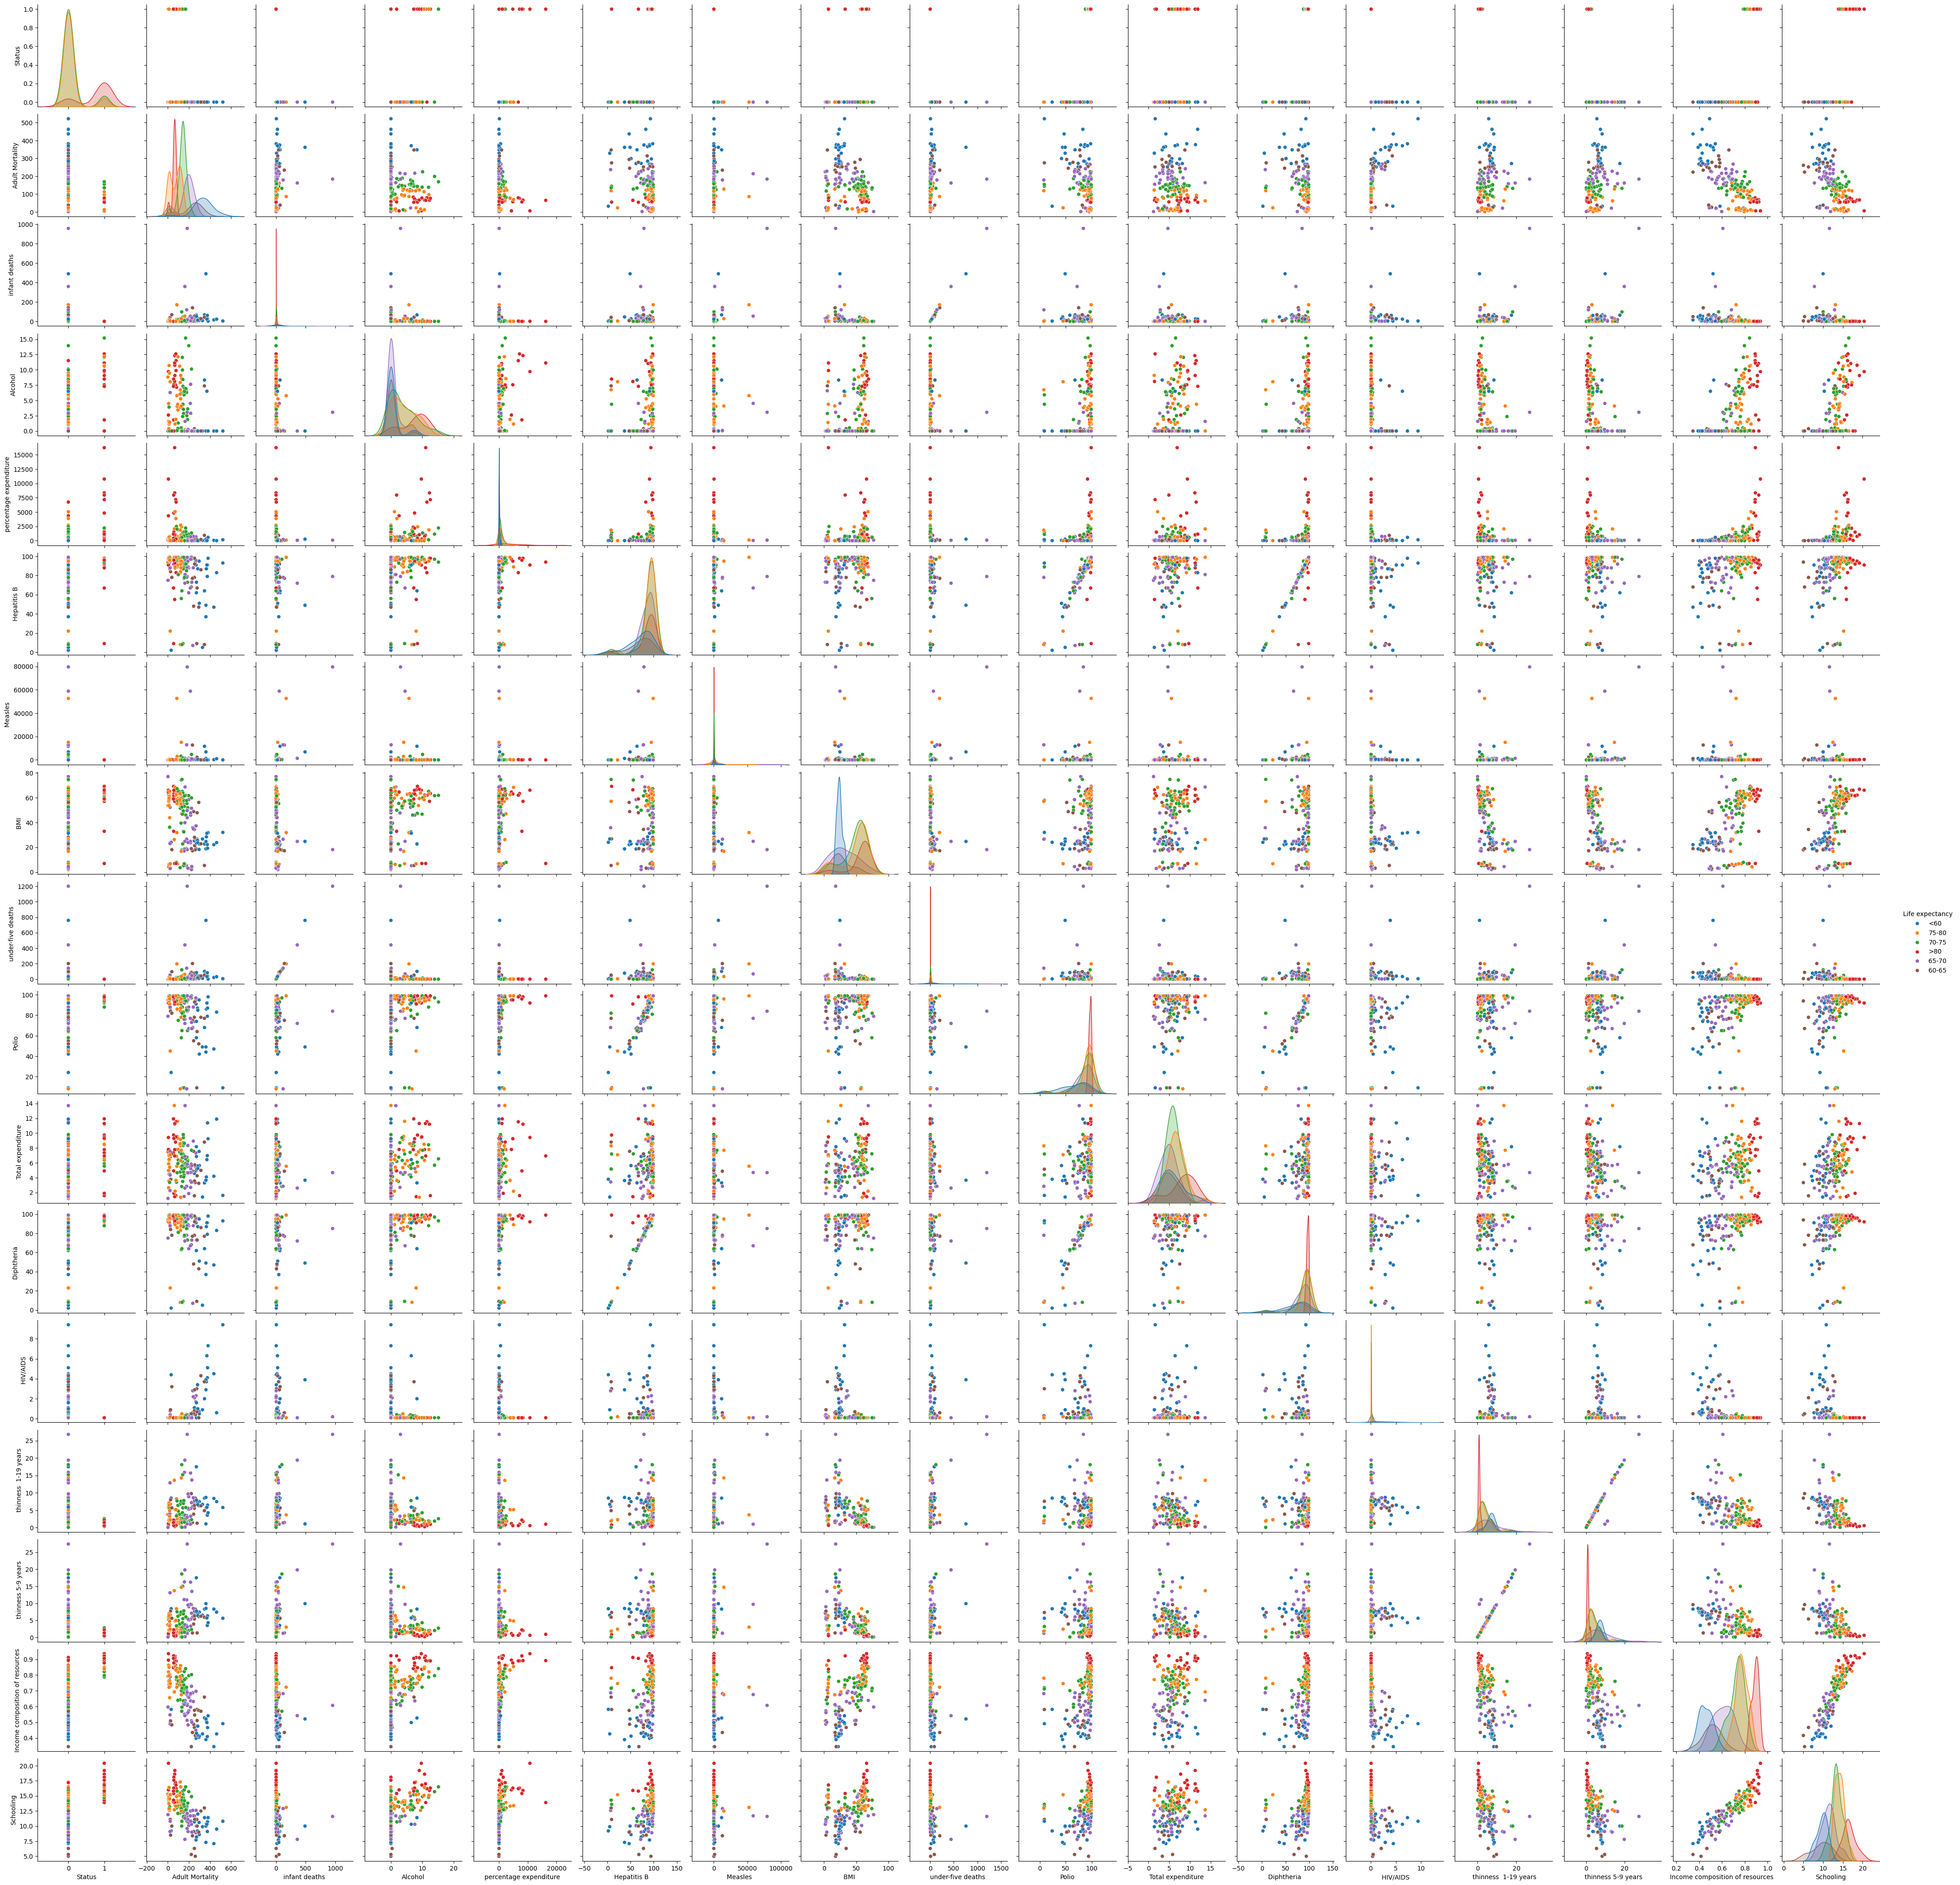

In [19]:
pic = sns.pairplot(df_who_to_year, hue='Life expectancy ');

Сделала такой график по инерции, как в домашке – в целом он мог бы помочь, если бы признаков было не так много, а переменная не была бы количественной. Ее можно скачать кодом ниже; но дальше будет график лучше.

По этой картинке можно делать какие-то выводы, но я пока запуталась и побоялась что-то убирать, поэтому посмотрим, как работает классификатор, если не убирать вообще никакие параметры:

In [17]:
pic.savefig('pairplot.jpg', dpi=300, bbox_inches='tight')
#скачать ненужную картинку без смс и регистрации

In [20]:
X = df_who_to_year.drop(['Life expectancy '], axis=1)
y_true = df_who_to_year[['Life expectancy ']]

model_1 = KNeighborsClassifier()
model_1.fit(X, y_true)

KNeighborsClassifier()

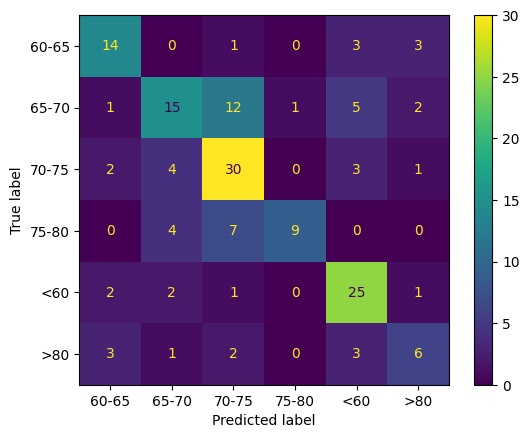

In [21]:
y_hat = model_1.predict(X)
actual_labels = sorted(set((y_hat)))
labels = df_who_to_year['Life expectancy '].unique()

matrix = confusion_matrix(y_true, y_hat, labels=labels, normalize=None)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=actual_labels)
disp.plot();

Очень так себе он работает – значит, вероятно, нужно убирать какие-то признаки.
Чтобы понять, какие именно, нужно вернуться к построению графиков – а там есть сложность, потому что да, я, конечно, попыталась сделать из численной переменной категориальную, но как будто (особенно с таким количеством признаков) pairplot для таких ситуаций, когда это не прямо классы (как в примере с ирисом), а непрерывная переменная, менее информативен (и – простите, это было важно – менее понятен...), чем, например, вот такой график с выделением искомого признака.

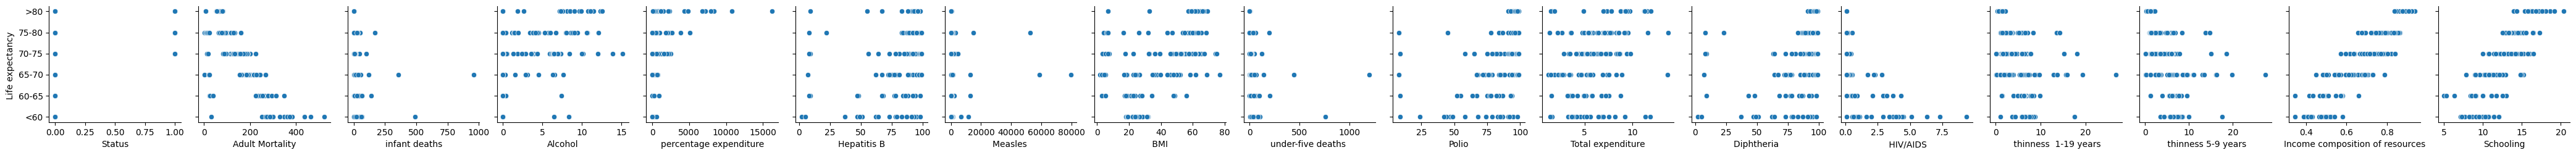

In [23]:
correct_order = ['>80', '75-80', '70-75', '65-70', '60-65', '<60']

df_who_to_year['Life expectancy '] = pd.Categorical(
    df_who_to_year['Life expectancy '],
    categories=correct_order,
    ordered=True
)

target = 'Life expectancy '
sns.pairplot(df_who_to_year,
             y_vars=[target],
             x_vars=df_who_to_year.columns.drop(target))
plt.show()

Мне вот на основании этого графика кажется не очень информативным признак кори, а еще не очень понятная корреляция с гепатитом В; то, что я хотела бы убрать еще – это алкоголь: там ощущение, как будто корреляция обратная (а связано оно скорее всего с тем, что просто среди развивающихся стран много буддистских и мусульманских, где алкоголь просто не пьют – а в развитых это не основная причина смерти), что явно может путать модель.

Короче: пока убираем корь, алкоголь и гепатит и наблюдаем.

In [24]:
df_modified_1 = df_who_to_year.drop(columns=
 ['Measles ', 'Hepatitis B', 'Alcohol'])
df_modified_1

,Status,Life expectancy,Adult Mortality,infant deaths,percentage expenditure,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1,0,<60,271.0,64,73.523582,18.6,86,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
17,0,75-80,8.0,0,428.749067,57.2,1,98.0,5.88,98.0,0.1,1.2,1.3,0.761,14.2
33,0,75-80,11.0,21,54.237318,58.4,24,95.0,7.21,95.0,0.1,6.0,5.8,0.741,14.4
49,0,<60,348.0,67,23.965612,22.7,101,68.0,3.31,64.0,2.0,8.5,8.3,0.527,11.4
65,0,75-80,131.0,0,2422.999774,47.0,0,96.0,5.54,99.0,0.2,3.3,3.3,0.782,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,0,70-75,158.0,9,0.000000,61.5,10,79.0,5.26,78.0,0.1,1.6,1.5,0.771,14.2
2875,0,75-80,128.0,28,0.000000,16.7,35,96.0,7.70,95.0,0.1,14.3,14.7,0.675,12.5
2891,0,65-70,228.0,37,0.000000,4.4,47,67.0,5.64,73.0,0.1,13.7,13.5,0.500,9.0
2907,0,60-65,314.0,28,196.667577,22.8,41,78.0,4.99,86.0,4.3,6.3,6.2,0.570,12.5


In [25]:
X = df_modified_1.drop(['Life expectancy '], axis=1)
y_true = df_modified_1['Life expectancy ']

model_2 = KNeighborsClassifier()
model_2.fit(X, y_true)

KNeighborsClassifier()

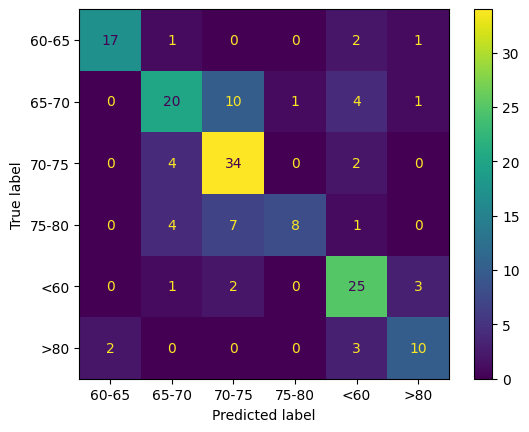

In [26]:
y_hat_2 = model_2.predict(X)
actual_labels = sorted(set((y_hat_2)))
labels = df_modified_1['Life expectancy '].unique()

matrix = confusion_matrix(y_true, y_hat_2, labels=labels, normalize=None)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=actual_labels)
disp.plot();

Вау, круто, стало немного лучше! Но я хочу еще немного поэксперементировать и убрать еще взрослую смертность – как будто это на самом деле статистика, которая коррелирует очевидным образом.

In [27]:
df_modified_2 = df_modified_1.drop(columns=['Adult Mortality'])
df_modified_2

,Status,Life expectancy,infant deaths,percentage expenditure,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1,0,<60,64,73.523582,18.6,86,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
17,0,75-80,0,428.749067,57.2,1,98.0,5.88,98.0,0.1,1.2,1.3,0.761,14.2
33,0,75-80,21,54.237318,58.4,24,95.0,7.21,95.0,0.1,6.0,5.8,0.741,14.4
49,0,<60,67,23.965612,22.7,101,68.0,3.31,64.0,2.0,8.5,8.3,0.527,11.4
65,0,75-80,0,2422.999774,47.0,0,96.0,5.54,99.0,0.2,3.3,3.3,0.782,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,0,70-75,9,0.000000,61.5,10,79.0,5.26,78.0,0.1,1.6,1.5,0.771,14.2
2875,0,75-80,28,0.000000,16.7,35,96.0,7.70,95.0,0.1,14.3,14.7,0.675,12.5
2891,0,65-70,37,0.000000,4.4,47,67.0,5.64,73.0,0.1,13.7,13.5,0.500,9.0
2907,0,60-65,28,196.667577,22.8,41,78.0,4.99,86.0,4.3,6.3,6.2,0.570,12.5


In [28]:
X = df_modified_2.drop(['Life expectancy '], axis=1)
y_true = df_modified_2['Life expectancy ']

model_3 = KNeighborsClassifier()
model_3.fit(X, y_true)

KNeighborsClassifier()

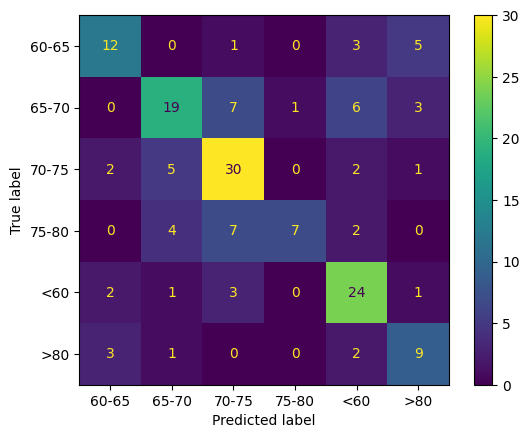

In [29]:
y_hat_3 = model_3.predict(X)
actual_labels = sorted(set((y_hat_3)))
labels = df_modified_2['Life expectancy '].unique()

matrix = confusion_matrix(y_true, y_hat_3, labels=labels, normalize=None)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=actual_labels)
disp.plot();

Нет, стало хуже, чем было до: видимо, эта информация важна модели. Последняя попытка – убрать детскую смертность (тоже выглядит не очень логичным, но там не очень высокие значения, не очень четкая корреляция увеличения этих значения и, возможно, это путает модель).

In [31]:
df_modified_3 = df_modified_1.drop(columns=['infant deaths',
                                            'under-five deaths '])
df_modified_3

,Status,Life expectancy,Adult Mortality,percentage expenditure,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1,0,<60,271.0,73.523582,18.6,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
17,0,75-80,8.0,428.749067,57.2,98.0,5.88,98.0,0.1,1.2,1.3,0.761,14.2
33,0,75-80,11.0,54.237318,58.4,95.0,7.21,95.0,0.1,6.0,5.8,0.741,14.4
49,0,<60,348.0,23.965612,22.7,68.0,3.31,64.0,2.0,8.5,8.3,0.527,11.4
65,0,75-80,131.0,2422.999774,47.0,96.0,5.54,99.0,0.2,3.3,3.3,0.782,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,0,70-75,158.0,0.000000,61.5,79.0,5.26,78.0,0.1,1.6,1.5,0.771,14.2
2875,0,75-80,128.0,0.000000,16.7,96.0,7.70,95.0,0.1,14.3,14.7,0.675,12.5
2891,0,65-70,228.0,0.000000,4.4,67.0,5.64,73.0,0.1,13.7,13.5,0.500,9.0
2907,0,60-65,314.0,196.667577,22.8,78.0,4.99,86.0,4.3,6.3,6.2,0.570,12.5


In [32]:
X = df_modified_3.drop(['Life expectancy '], axis=1)
y_true = df_modified_3['Life expectancy ']

model_4 = KNeighborsClassifier()
model_4.fit(X, y_true)

KNeighborsClassifier()

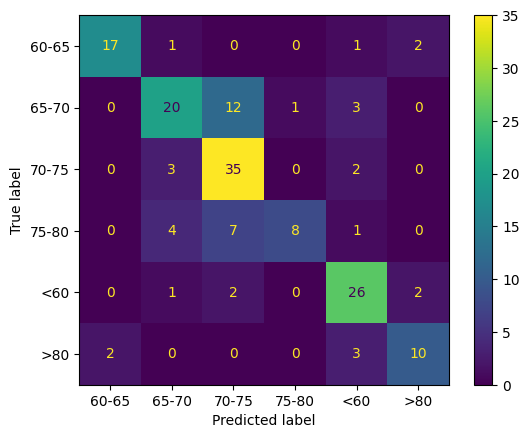

In [33]:
y_hat_4 = model_4.predict(X)
actual_labels = sorted(set((y_hat_4)))
labels = df_modified_3['Life expectancy '].unique()

matrix = confusion_matrix(y_true, y_hat_4, labels=labels, normalize=None)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=actual_labels)
disp.plot();

Стало чуть-чуть лучше (кстати, интересное наблюдение: по отдельности ни один из признаков, связанных с детской смертностью, улучшений не давал – а вот вместе дали; вероятно, это связано с тем, что эти два признака почти коллинеарны друг другу). На этом я, наверное, хочу временно закончить попытки убрать признаки и начать учить модель.

###Обучение классификатора

In [87]:
X = df_modified_3.drop(['Life expectancy '], axis=1)
y = df_modified_3['Life expectancy ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=1
    )

In [88]:
k_best = -1
best_accuracy = 0

for k in range(1, 10):
    y_predicted = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).predict(X_val)

    val_accuracy = accuracy_score(y_val, y_predicted)
    print(f'k = {k}; accuracy = {val_accuracy:.3f}')

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        k_best = k

print('\nk_best =', k_best)

k = 1; accuracy = 0.654
k = 2; accuracy = 0.538
k = 3; accuracy = 0.577
k = 4; accuracy = 0.577
k = 5; accuracy = 0.577
k = 6; accuracy = 0.500
k = 7; accuracy = 0.462
k = 8; accuracy = 0.577
k = 9; accuracy = 0.538

k_best = 1


In [89]:
knn = KNeighborsClassifier(n_neighbors=k_best)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [90]:
preds = knn.predict(X_test)

print(classification_report(preds, y_test))

              precision    recall  f1-score   support

       60-65       0.50      0.50      0.50         2
       65-70       0.56      0.62      0.59         8
       70-75       0.60      0.46      0.52        13
       75-80       0.33      0.33      0.33         6
         <60       0.75      1.00      0.86         3
         >80       0.00      0.00      0.00         1

    accuracy                           0.52        33
   macro avg       0.46      0.49      0.47        33
weighted avg       0.53      0.52      0.52        33



Поиграла с разным количеством k (не помогло), размерами тестовых выборок (помогло) – но итого все равно больше 0.52 оно не поднимается.

Единственный способ, который я вспомнила, чтобы что-то с этим сделать – масштабирование:

In [63]:
from sklearn.preprocessing import StandardScaler

X = df_modified_3.drop(['Life expectancy '], axis=1)
y = df_modified_3['Life expectancy ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.4, random_state=1
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

k_best = -1
best_accuracy = 0

for k in range(1, 10):
    y_predicted = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train).predict(X_val_scaled)

    val_accuracy = accuracy_score(y_val, y_predicted)
    print(f'k = {k}; accuracy = {val_accuracy:.3f}')

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        k_best = k

print('\nk_best =', k_best)

knn = KNeighborsClassifier(n_neighbors=k_best)
knn.fit(X_train_scaled, y_train)

k = 1; accuracy = 0.510
k = 2; accuracy = 0.388
k = 3; accuracy = 0.469
k = 4; accuracy = 0.531
k = 5; accuracy = 0.633
k = 6; accuracy = 0.551
k = 7; accuracy = 0.510
k = 8; accuracy = 0.592
k = 9; accuracy = 0.571

k_best = 5


KNeighborsClassifier()

In [64]:
preds = knn.predict(X_test_scaled)

print(classification_report(preds, y_test))

              precision    recall  f1-score   support

       60-65       0.33      0.20      0.25         5
       65-70       0.20      1.00      0.33         2
       70-75       0.85      0.61      0.71        18
       75-80       0.62      0.62      0.62         8
         <60       0.80      0.50      0.62         8
         >80       0.00      0.00      0.00         0

    accuracy                           0.56        41
   macro avg       0.47      0.49      0.42        41
weighted avg       0.70      0.56      0.60        41



<Figure size 800x600 with 0 Axes>

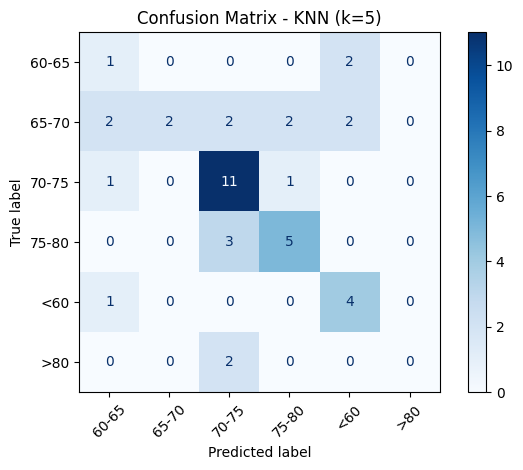

Confusion Matrix:


In [72]:
y_test_pred = knn.predict(X_test_scaled)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=knn.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - KNN (k={k_best})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")

In [65]:
r2_train = knn.score(X_train_scaled, y_train)
r2_test = knn.score(X_test_scaled, y_test)

print(r2_train, r2_test)

0.7671232876712328 0.5609756097560976


Ну...

В общем, точность 0.56 – это роскошный максимум, которого мне удалось добиться масштабированием и игранием в размеры тестовых и валидационных выборок

##Короткая интерпретация

мысли о данных:

*   работать вслепую, не зная, какой шаг в продолжительности жизни реально важен – вплоть до десятой части года? года? пяти лет? десяти лет? – довольно сложно (это влияет на интерпретацию качества)
*   напрашивается вывод про неравномерность данных(( 75-80 лет явно прям перевешивает, и это ощутимо влияет на качество предсказания

мысли о результатах:


*   она ошибается в классификации близких значений, что на самом деле менее страшно, чем если бы это была бинарная классификация. то есть, вообще 50% правильных предсказаний – это буквально угадывание, но здесь если посмотреть на матрицу – она угадывает, просто не очень точно
*   размер тестовой и валидационной выборок, как его ни меняй, нормально не дает никакой равномерности




##Обучение модели линейной регрессии

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score

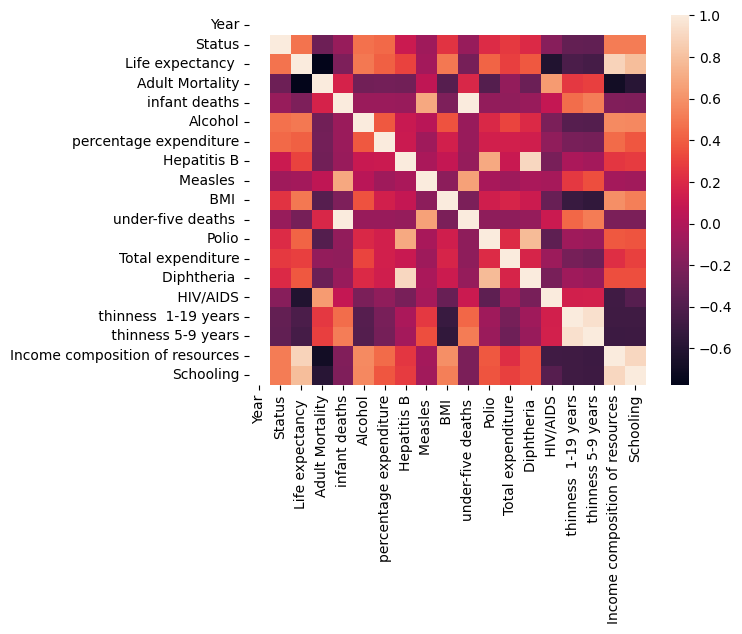

In [101]:
sns.heatmap(who_df_final.corr('pearson'));

Видно, что в целом прям уж большая корреляция есть только между детскими смертностями (как уже было понятно выше); если модель будет путаться, их можно будет просто удалить потом. Есть какие-то соотношения, близкие к корреляциями – например, между алкоголем и income composition of resources, – в правдоподобности которых я не уверена и с которыми пока ничего делать не стала бы. С обоими из этих признаков правда, кажется, может коррелировать искомая величина (и чуть меньше -- со статусом и процентом расходов)

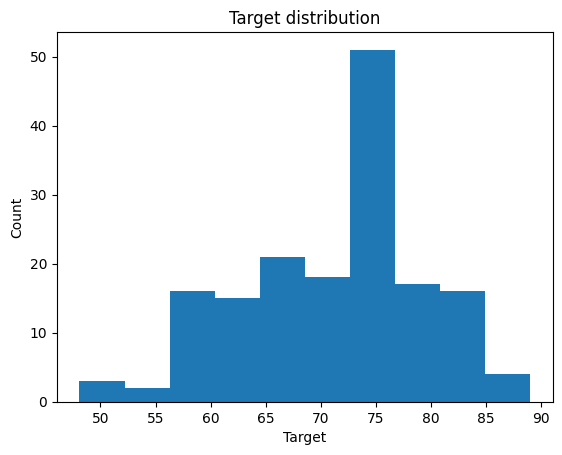

In [106]:
fig, ax = plt.subplots()
ax.hist(who_df_final['Life expectancy '])
ax.set_title('Target distribution')
ax.set_xlabel('Target')
ax.set_ylabel('Count');

Распределение выглядит чуть равномернее для этой задачи, чем для предыдущей

In [157]:
train, test = train_test_split(who_df_final, test_size=0.3, random_state=42)
train.shape, test.shape

#опытным путем было проверено, что самый высокий результат именно с 0.3 тут

((114, 19), (49, 19))

In [158]:
np.random.seed(42)

In [159]:
x_train, y_train = train.loc[:, :'Adult Mortality'].to_numpy(), \
    train['Life expectancy '].to_numpy()

x_test, y_test = test.loc[:, :'Adult Mortality'].to_numpy(), \
    test['Life expectancy '].to_numpy()

In [160]:
mn = y_train.mean()
pred = [mn for _ in y_test]
r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(-0.022799110163299607, 6.684586466165413)

Какой-то жуткий результат; зато узнали, что средняя ошибка – в районе 7 [лет]

In [161]:
x_train = train.drop(columns=['Life expectancy ']).to_numpy()
y_train = train['Life expectancy '].to_numpy()

x_test = test.drop(columns=['Life expectancy ']).to_numpy()
y_test = test['Life expectancy '].to_numpy()

In [162]:
reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [163]:
pred = reg.predict(x_test)
r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(0.767371184930121, 3.0689808916938626)

Что получилось: значение r2 в общем-то хорошее, средняя ошибка в два с лишним раза меньше, чем посчитанная в относительно случайном эксперименте -> результат хороший, несмотря на небольшую неравномерность в данных.

В прошлый раз мне чуть-чуть помогло убирание признаков детской смертности (обоих) – давайте попробуем сделать это еще раз.

In [169]:
df_modified_1_2 = who_df_final.drop(columns=['infant deaths',
                                            'under-five deaths '])

In [182]:
train, test = train_test_split(df_modified_1_2, test_size=0.3, random_state=42)
train.shape, test.shape

((105, 17), (58, 17))

In [179]:
x_train = train.drop(columns=['Life expectancy ']).to_numpy()
y_train = train['Life expectancy '].to_numpy()

x_test = test.drop(columns=['Life expectancy ']).to_numpy()
y_test = test['Life expectancy '].to_numpy()

In [180]:
reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [181]:
pred = reg.predict(x_test)
r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(0.7476282535169709, 3.391495593526839)

Нет, не очень помогло:(
Пробуем масштабирование (вдруг поможет)

In [221]:
train, test = train_test_split(who_df_final, test_size=0.3, random_state=42)
train.shape, test.shape

((114, 19), (49, 19))

In [222]:
x_train = train.drop(columns=['Life expectancy ']).to_numpy()
y_train = train['Life expectancy '].to_numpy()

x_test = test.drop(columns=['Life expectancy ']).to_numpy()
y_test = test['Life expectancy '].to_numpy()

scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [223]:
ridge_unscaled = Ridge(alpha=1.0)
ridge_unscaled.fit(x_train, y_train)

ridge_scaled = Ridge(alpha=1.0)
ridge_scaled.fit(x_train_scaled, y_train)

Ridge()

In [224]:
reg = LinearRegression()
reg.fit(x_train_scaled, y_train)

LinearRegression()

In [225]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_scaled, y_train)
pred = ridge.predict(x_test_scaled)
r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(0.7676676286431354, 3.0592587246336147)

Помогло совсем-совсем немного

In [226]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5, max_iter=10000)
lasso.fit(x_train_scaled, y_train)
pred_lasso = lasso.predict(x_test_scaled)
r2_score(y_test, pred_lasso)

0.7723903429070238

Тоже помогло, но совсем немного:(

In [233]:
df_modified_2_2 = who_df_final.drop(columns=['Alcohol'])

In [234]:
train, test = train_test_split(df_modified_2_2, test_size=0.3, random_state=42)
train.shape, test.shape

((114, 18), (49, 18))

In [237]:
x_train = train.drop(columns=['Life expectancy ']).to_numpy()
y_train = train['Life expectancy '].to_numpy()

x_test = test.drop(columns=['Life expectancy ']).to_numpy()
y_test = test['Life expectancy '].to_numpy()

In [238]:
reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [239]:
pred = reg.predict(x_test)
r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(0.7693565028942638, 3.082061016327128)

Вот кстати: убирание алкоголя помогло относительно первого результата; я пыталась наложить на это предыдущие манипуляции с масштабированием, но это не привело к особому успеху, поэтому окей, оставлю так

максимальное полученное значение r^2 – 0,772

СТОП пожалуйста не снижайте сильно за дедлайн я вспомнила о существовании градиентного бустинга
это все еще не 0,8 но ПОЧТИ ЖЕ

In [256]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(x_train, y_train)
pred = gb.predict(x_test)
r2_score(y_test, pred)

0.7994455505156924